In [1]:
from pathlib import Path

required_files = [
    "week2_Xtr.npy",
    "week2_ytr.npy",
    "week2_Xte.npy",
    "week2_yte.npy",
    "week2_checkpoint.pth",
    "week2_trial_split.csv"
]

for filename in required_files:
    status = "OK" if Path(filename).is_file() else "MISSING"
    print(f"{status}: {filename}")

OK: week2_Xtr.npy
OK: week2_ytr.npy
OK: week2_Xte.npy
OK: week2_yte.npy
OK: week2_checkpoint.pth
OK: week2_trial_split.csv


In [3]:
import numpy as np
import pandas as pd

Xtr = np.load("week2_Xtr.npy")
ytr = np.load("week2_ytr.npy")
Xte = np.load("week2_Xte.npy")
yte = np.load("week2_yte.npy")

print("Training data:", Xtr.shape)
print("Training labels:", ytr.shape)
print("Test data:", Xte.shape)
print("Test labels:", yte.shape)

# Check that data and labels match
assert len(Xtr) == len(ytr)
assert len(Xte) == len(yte)
assert Xtr.shape[1:] == (3, 32, 300)
assert Xte.shape[1:] == (3, 32, 300)
assert np.isfinite(Xtr).all() and np.isfinite(Xte).all()

# Check the saved trial split
split_table = pd.read_csv("week2_trial_split.csv")

train_trials = set(
    split_table.loc[split_table["split"] == "train", "file"]
)
test_trials = set(
    split_table.loc[split_table["split"] == "test", "file"]
)

assert train_trials.isdisjoint(test_trials)

print("Shared trials:", len(train_trials & test_trials))
print("Data checks passed!")

Training data: (3800, 3, 32, 300)
Training labels: (3800,)
Test data: (950, 3, 32, 300)
Test labels: (950,)
Shared trials: 0
Data checks passed!


In [5]:
import torch
import torch.nn as nn
from torchvision.models import densenet161

# Choose the available device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Load your saved checkpoint
checkpoint = torch.load(
    "week2_checkpoint.pth",
    map_location="cpu",
    weights_only=True
)

label_map = checkpoint["label_map"]
class_names = sorted(label_map, key=label_map.get)

# Re-create the same model structure
dense_model = densenet161(weights=None)
dense_model.classifier = nn.Linear(
    dense_model.classifier.in_features,
    len(class_names)
)

# Restore the trained weights
dense_model.load_state_dict(checkpoint["model_state_dict"])
dense_model = dense_model.to(device)
dense_model.eval()

print("Device:", device)
print("Completed epochs:", checkpoint["epoch"])
print("Classes:", class_names)

# Check predictions for two test windows
with torch.no_grad():
    sample = torch.from_numpy(Xte[:2]).to(device)
    output = dense_model(sample)

print("Output shape:", output.shape)
print("Outputs are finite:", torch.isfinite(output).all().item())

Device: mps
Completed epochs: 5
Classes: ['A', 'B', 'C', 'D', 'E']
Output shape: torch.Size([2, 5])
Outputs are finite: True


,Model,Accuracy,Precision,Recall,F1-score
0,DenseNet161,0.8474,0.8609,0.8474,0.8474


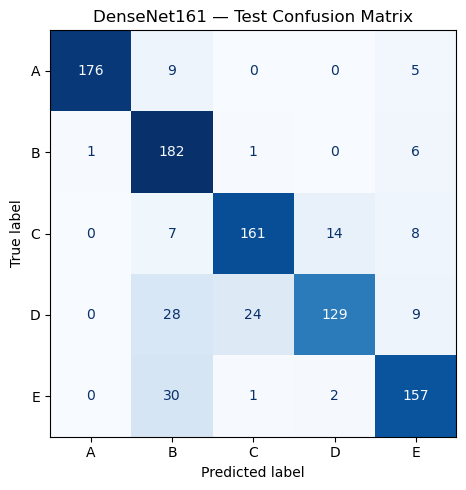

In [7]:
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(Xte),
        torch.from_numpy(yte)
    ),
    batch_size=16,
    shuffle=False,
    num_workers=0
)

# Reuse this function for the second model later
def evaluate_model(model):
    model.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb.to(device))
            predictions = outputs.argmax(dim=1)

            true_labels.extend(yb.numpy())
            predicted_labels.extend(predictions.cpu().numpy())

    return np.array(true_labels), np.array(predicted_labels)


dense_true, dense_pred = evaluate_model(dense_model)

class_ids = [label_map[name] for name in class_names]

precision, recall, f1, _ = precision_recall_fscore_support(
    dense_true,
    dense_pred,
    labels=class_ids,
    average="macro",
    zero_division=0
)

dense_results = {
    "Model": "DenseNet161",
    "Accuracy": accuracy_score(dense_true, dense_pred),
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

results_table = pd.DataFrame([dense_results])
display(results_table.round(4))

results_table.to_csv("week3_densenet_metrics.csv", index=False)

# Save actual predictions for later analysis
pd.DataFrame({
    "true_label": dense_true,
    "predicted_label": dense_pred
}).to_csv("week3_densenet_predictions.csv", index=False)

# Draw and save the confusion matrix
dense_cm = confusion_matrix(
    dense_true, dense_pred, labels=class_ids
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=dense_cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("DenseNet161 — Test Confusion Matrix")
plt.tight_layout()
plt.savefig("week3_densenet_confusion_matrix.png", dpi=150)
plt.show()

In [9]:
import time

torch.manual_seed(42)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


cnn_model = SimpleCNN(len(class_names)).to(device)

train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(Xtr),
        torch.from_numpy(ytr)
    ),
    batch_size=16,
    shuffle=True,
    num_workers=0
)

cnn_optimizer = torch.optim.Adam(
    cnn_model.parameters(), lr=0.001
)
criterion = nn.CrossEntropyLoss()

cnn_history = []
epochs = int(checkpoint["epoch"])

for epoch in range(1, epochs + 1):
    cnn_model.train()
    start = time.perf_counter()
    total_loss = 0.0
    total_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        cnn_optimizer.zero_grad()
        outputs = cnn_model(xb)
        loss = criterion(outputs, yb)

        if not torch.isfinite(loss).item():
            raise RuntimeError("Loss became NaN or infinite.")

        loss.backward()
        cnn_optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_samples += xb.size(0)

    average_loss = total_loss / total_samples
    elapsed = time.perf_counter() - start

    cnn_history.append({
        "epoch": epoch,
        "train_loss": average_loss,
        "seconds": elapsed
    })

    print(
        f"Epoch {epoch}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Time: {elapsed:.1f} seconds",
        flush=True
    )

    pd.DataFrame(cnn_history).to_csv(
        "week3_cnn_training_log.csv", index=False
    )

    torch.save({
        "epoch": epoch,
        "model_state_dict": cnn_model.state_dict(),
        "optimizer_state_dict": cnn_optimizer.state_dict(),
        "label_map": label_map,
        "history": cnn_history
    }, "week3_cnn_checkpoint.pth")

print("CNN training finished!")
display(pd.DataFrame(cnn_history))

Epoch 1/5 | Loss: 1.2954 | Time: 8.5 seconds
Epoch 2/5 | Loss: 1.0892 | Time: 4.4 seconds
Epoch 3/5 | Loss: 1.0294 | Time: 4.4 seconds
Epoch 4/5 | Loss: 1.0065 | Time: 4.3 seconds
Epoch 5/5 | Loss: 0.9918 | Time: 4.3 seconds
CNN training finished!


,epoch,train_loss,seconds
0,1,1.295370,8.521252
1,2,1.089162,4.358530
2,3,1.029406,4.440802
3,4,1.006484,4.324857
4,5,0.991791,4.298495


,Accuracy,Precision,Recall,F1-score
Model,,,,
DenseNet161,84.74,86.09,84.74,84.74
Simple 2D CNN,58.63,58.56,58.63,57.16


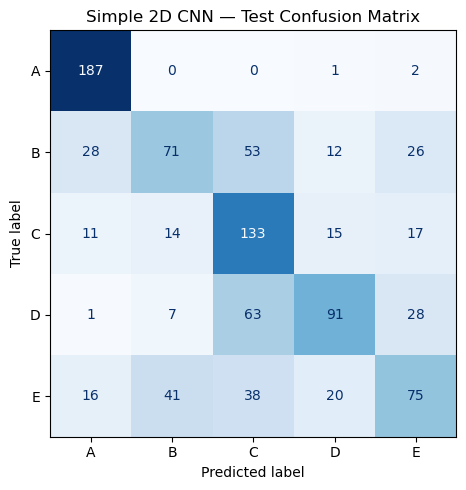

In [11]:
cnn_true, cnn_pred = evaluate_model(cnn_model)

precision, recall, f1, _ = precision_recall_fscore_support(
    cnn_true,
    cnn_pred,
    labels=class_ids,
    average="macro",
    zero_division=0
)

cnn_results = {
    "Model": "Simple 2D CNN",
    "Accuracy": accuracy_score(cnn_true, cnn_pred),
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

# Save CNN predictions
pd.DataFrame({
    "true_label": cnn_true,
    "predicted_label": cnn_pred
}).to_csv("week3_cnn_predictions.csv", index=False)

# Compare both models
comparison = pd.DataFrame([dense_results, cnn_results])
comparison.to_csv("week3_model_comparison.csv", index=False)

# Display metrics as percentages
comparison_percent = comparison.set_index("Model") * 100
display(comparison_percent.round(2))

# Draw the CNN confusion matrix
cnn_cm = confusion_matrix(
    cnn_true, cnn_pred, labels=class_ids
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=class_names
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_title("Simple 2D CNN — Test Confusion Matrix")
plt.tight_layout()
plt.savefig("week3_cnn_confusion_matrix.png", dpi=150)
plt.show()

In [13]:
def analyze_confusion(cm, model_name):
    totals = cm.sum(axis=1)
    correct = np.diag(cm)
    errors = totals - correct

    recall = np.divide(
        correct,
        totals,
        out=np.zeros(len(totals), dtype=float),
        where=totals != 0
    )

    table = pd.DataFrame({
        "Class": class_names,
        "Test windows": totals,
        "Correct": correct,
        "Incorrect": errors,
        "Recall (%)": np.round(recall * 100, 2)
    })

    print(f"\n{model_name}")
    display(table)

    # Include all tied classes
    best = [
        class_names[i]
        for i in range(len(class_names))
        if recall[i] == recall.max()
    ]
    most_errors = [
        class_names[i]
        for i in range(len(class_names))
        if errors[i] == errors.max()
    ]

    print("Highest class recall:", ", ".join(best))

    if errors.sum() == 0:
        print("No misclassifications.")
    else:
        print("Most incorrectly classified:", ", ".join(most_errors))

        off_diagonal = cm.copy()
        np.fill_diagonal(off_diagonal, 0)
        largest_error = off_diagonal.max()

        print("Most common mistakes (actual → predicted):")
        for actual, predicted in np.argwhere(
            off_diagonal == largest_error
        ):
            print(
                f"  {class_names[actual]} → "
                f"{class_names[predicted]}: "
                f"{largest_error} windows"
            )

    return table


dense_analysis = analyze_confusion(dense_cm, "DenseNet161")
cnn_analysis = analyze_confusion(cnn_cm, "Simple 2D CNN")

dense_analysis.to_csv(
    "week3_densenet_class_analysis.csv", index=False
)
cnn_analysis.to_csv(
    "week3_cnn_class_analysis.csv", index=False
)


DenseNet161


,Class,Test windows,Correct,Incorrect,Recall (%)
0,A,190,176,14,92.63
1,B,190,182,8,95.79
2,C,190,161,29,84.74
3,D,190,129,61,67.89
4,E,190,157,33,82.63


Highest class recall: B
Most incorrectly classified: D
Most common mistakes (actual → predicted):
  E → B: 30 windows

Simple 2D CNN


,Class,Test windows,Correct,Incorrect,Recall (%)
0,A,190,187,3,98.42
1,B,190,71,119,37.37
2,C,190,133,57,70.00
3,D,190,91,99,47.89
4,E,190,75,115,39.47


Highest class recall: A
Most incorrectly classified: B
Most common mistakes (actual → predicted):
  D → C: 63 windows


## Confusion Matrix 분석

### DenseNet161
- 가장 잘 분류된 클래스: B로, 190개 중 182개를 맞혀 재현율 95.79%를 기록하였다.
- 가장 많이 오분류된 클래스: D로, 190개 중 61개를 잘못 분류하였다.
- 주요 오분류 유형: 실제 E를 B로 예측한 경우가 30개로 가장 많았다.
- 가능한 원인: E와 B의 근전도 특징이 일부 비슷하거나, 5에폭 학습만으로 차이를 충분히 배우지 못했을 수 있다. 정확한 원인은 추가 실험이 필요하다.

### Simple 2D CNN
- 가장 잘 분류된 클래스: A로, 190개 중 187개를 맞혀 재현율 98.42%를 기록하였다.
- 가장 많이 오분류된 클래스: B로, 190개 중 119개를 잘못 분류하였다.
- 주요 오분류 유형: 실제 D를 C로 예측한 경우가 63개로 가장 많았다.
- 가능한 원인: 단순한 모델 구조와 짧은 학습으로 개인별 신호 차이를 충분히 배우지 못했을 수 있다. 다만 혼동행렬만으로 원인을 확정할 수는 없다.

### 결과 요약
이번 5에폭 실험에서 DenseNet161의 정확도는 84.74%, Simple 2D CNN은 58.63%였다.
CNN은 A를 잘 분류했지만, DenseNet161은 나머지 네 클래스에서 더 높은 재현율을 보였다.
이 결과는 한 번의 데이터 분할과 학습에서 얻은 결과이므로, 모델의 일반적인 우수성을 확정하려면 추가 실험이 필요하다.

In [16]:
print(comparison_percent.round(2).to_string())

               Accuracy  Precision  Recall  F1-score
Model                                               
DenseNet161       84.74      86.09   84.74     84.74
Simple 2D CNN     58.63      58.56   58.63     57.16


## 모델 성능 비교

모든 값의 단위는 %이며, Precision, Recall, F1-score는 macro 평균이다.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| DenseNet161 | 84.74 | 86.09 | 84.74 | 84.74 |
| Simple 2D CNN | 58.63 | 58.56 | 58.63 | 57.16 |

두 모델에 동일한 학습·테스트 데이터와 5에폭 학습 조건을 적용하였다.
DenseNet161이 네 가지 평가 지표에서 모두 더 높은 성능을 보였다.
DenseNet의 특징 재사용 구조가 개인별 신호 차이를 학습하는 데 도움이 되었을 가능성이 있지만, 이번 실험만으로 원인을 확정할 수는 없다.

## 최종 결과

- 가장 성능이 좋은 모델: DenseNet161
- 가장 성능이 낮은 모델: Simple 2D CNN
- 주요 오분류: DenseNet161은 E → B, Simple 2D CNN은 D → C
- 실험 범위: 등록된 5명을 구별하는 실험이며, 미등록자 판별은 평가하지 않았다.

이번 실험에서 DenseNet161은 정확도 84.74%, macro F1-score 84.74%를 기록하였다.
Simple 2D CNN은 정확도 58.63%, macro F1-score 57.16%를 기록하였다.
전체 정확도뿐만 아니라 혼동행렬을 함께 확인해야 어떤 클래스를 잘못 분류하는지 알 수 있었다.
또한 겹치는 윈도우가 학습과 테스트에 함께 들어가지 않도록 시행 단위로 먼저 나누는 것이 중요하다는 점을 배웠다.
이번 결과는 5에폭의 단일 실행 결과이므로, 반복 실험과 추가 학습을 통해 결과가 유지되는지 확인할 필요가 있다.